# Kaggle PlayGround 2026年4月実施分


## Cassava Leaf Disease Classification

[https://www.kaggle.com/competitions/cassava-leaf-disease-classification/](https://www.kaggle.com/competitions/cassava-leaf-disease-classification/)

> #### 3月時点：次回の目標の振り返り
>
> * ペナルティの影響が強すぎたためパラメータチューニングによりペナルティの調整をする
>
>* epochや調整した結果がどのような作用をするか知る
>
>* 自力モデルで画像タスクの根本を徹底的に理解する
>
>* シンプルCNNを経て高精度モデル（事前学習済みモデルやファインチューニング、転移学習など）でどのような結果が出るか試す
>

#### 今回の目標

**実施内容**
* パラメータチューニングをやってみる
* 前回結果とどのような差が出たか検証してみる
* 自力モデルタスクの完成

**余裕があればチャレンジ**
* 高精度モデルでどのような結果がでるか試す

### ライブラリインポートとデータの読み込み

In [ ]:
pip -q install japanize-matplotlib

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.1/4.1 MB 65.2 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done


In [ ]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import japanize_matplotlib
import seaborn as sns
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from PIL import Image
import cv2
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report

In [ ]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'{device} を使用')

cuda を使用


In [ ]:
# APIトークンを設定
os.environ['KAGGLE_API_TOKEN'] = "KGAT_de99c63f5c523fecaac2558f696af973"

print("APIトークンのセットアップが完了しました！データのダウンロードを開始します...")

# コンペティションのデータを一括ダウンロード
!kaggle competitions download -c cassava-leaf-disease-classification

# データを解凍して専用のフォルダ（cassava-data）にまとめる
!unzip -q cassava-leaf-disease-classification.zip -d cassava-data

print("\nデータのダウンロードと解凍が完了しました！")

APIトークンのセットアップが完了しました！データのダウンロードを開始します...
100% 5.76G/5.76G [01:19<00:00, 78.3MB/s]


データのダウンロードと解凍が完了しました！


In [ ]:
# CSVファイルを読み込んで先頭5行を表示
df = pd.read_csv('./cassava-data/train.csv')
print(f"学習データの総数: {len(df)} 件\n")
print(df.head())

# 画像フォルダの中身を数える
image_files = os.listdir('./cassava-data/train_images')
print(f"\nダウンロードされた画像枚数: {len(image_files)} 枚")

学習データの総数: 21397 件

         image_id  label
0  1000015157.jpg      0
1  1000201771.jpg      3
2   100042118.jpg      1
3  1000723321.jpg      1
4  1000812911.jpg      3

ダウンロードされた画像枚数: 21397 枚


<b>病名と症状について</b>

<details>
<summary>0: Cassava Bacterial Blight (CBB: 細菌性胴枯病)</summary>

**症状**  
- 葉の黒色斑点、葉の先端が枯れる  
- 若い葉や茎に水浸状の病斑  
- 最終的に植物全体が枯れることも  

**影響**  
- 葉が落ちて光合成低下  
- 根の生育も阻害、収量減少  

**特徴**  
- 高湿度で広がりやすい  
- 伝染力が強く、農家で管理が大変  

</details>

<details>
<summary>1: Cassava Brown Streak Disease (CBSD: 褐条病)</summary>

**症状**  
- 葉の黄化や黄色い斑点  
- 茎に茶色の縦条  
- 根に内部褐変（食用根が腐ったようになる）  

**影響**  
- 根の品質低下 → 食用・市場価値が減る  
- 収量低下  

**特徴**  
- 根に症状が出るのが特徴的  
- アフリカ東部で特に被害が深刻  

</details>

<details>
<summary>2: Cassava Green Mottle (CGM: 緑斑モザイク病)</summary>

**症状**  
- 葉に明暗のモザイク状の斑点（緑と薄緑のまだら模様）  
- 若い葉に特に症状が出やすい  

**影響**  
- 光合成効率低下 → 生育不良  
- 根の収量も減る  

**特徴**  
- 病気自体は軽度なこともあるが、複合感染すると深刻化  
- アフリカで最も広く被害がある病気  
- 白斑やモザイク模様が分かりやすく、葉の症状が典型的  

</details>

<details>
<summary>3: Cassava Mosaic Disease (CMD: モザイク病)</summary>

**症状**  
- 葉が縮れ、モザイク状の黄緑斑  
- 新葉が小さく変形  
- 根の発育不良  

**影響**  
- 葉の光合成低下 → 生育全体に影響  
- 収量が大幅に下がる  

**特徴**  
- アフリカで最も広く被害がある病気  
- 白斑やモザイク模様が分かりやすく、葉の症状が典型的  

</details>

<details>
<summary>4: Healthy (健康)</summary>

**症状**  
- 病気の症状なし  

**影響**  
- なし  

**特徴**  
- 葉は緑色で正常に光合成が行われている  
- 根も正常に肥大している  

</details>

### 前回のシンプルCNN再現

In [ ]:
# Datasetクラスの定義 (使う前に書く！)
class CassavaDataset(Dataset):
    def __init__(self, dataframe, image_dir, transform=None):
        self.dataframe = dataframe
        self.image_dir = image_dir
        self.transform = transform

    def __len__(self):
        return len(self.dataframe)

    def __getitem__(self, idx):
        img_name = self.dataframe.iloc[idx]['image_id']
        label = self.dataframe.iloc[idx]['label']
        img_path = os.path.join(self.image_dir, img_name)
        image = Image.open(img_path).convert('RGB')

        if self.transform:
            image = self.transform(image)
        return image, label

# モデルの定義
class SimpleCNN(nn.Module):
    def __init__(self, num_classes=5):
        super(SimpleCNN, self).__init__()
        self.conv1 = nn.Conv2d(3, 16, kernel_size=3, padding=1)
        self.pool = nn.MaxPool2d(kernel_size=2, stride=2)
        self.conv2 = nn.Conv2d(16, 32, kernel_size=3, padding=1)
        self.conv3 = nn.Conv2d(32, 64, kernel_size=3, padding=1)
        self.fc1 = nn.Linear(64 * 32 * 32, 512)
        self.fc2 = nn.Linear(512, num_classes)

    def forward (self, x):
        x = self.pool(F.relu(self.conv1(x)))
        x = self.pool(F.relu(self.conv2(x)))
        x = self.pool(F.relu(self.conv3(x)))
        x = x.view(-1, 64 * 32 * 32)
        x = F.relu(self.fc1(x))
        x = self.fc2(x)
        return x

# データの読み込みと分割
df = pd.read_csv('./cassava-data/train.csv')
train_df, val_df = train_test_split(df, test_size=0.2, stratify=df['label'], random_state=42)

# Transformの定義
train_transform = transforms.Compose([
    # 画像の一部をランダムに切り抜き、256×256にリサイズ
    transforms.RandomResizedCrop(256, scale=(0.8, 1.0)),

    # 50% の確率で画像を左右反転
    transforms.RandomHorizontalFlip(p=0.5),

    # 50% の確率で画像を上下反転
    transforms.RandomVerticalFlip(p=0.5),

    # 最大45度の範囲で画像をランダムに回転
    transforms.RandomRotation(degrees=15),

    # 明るさとコントラストをランダムに±20% 変更
    transforms.ColorJitter(brightness=0.2, contrast=0.2),

    # 画像をTensorに変換
    transforms.ToTensor(),
])


test_transform = transforms.Compose([
    transforms.Resize((256, 256)),
    transforms.ToTensor()
])

# DatasetとLoaderの作成
train_dataset = CassavaDataset(train_df, './cassava-data/train_images', transform=train_transform)
val_dataset = CassavaDataset(val_df, './cassava-data/train_images', transform=test_transform)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False)

# モデルのインスタンス化
model = SimpleCNN().to(device)
print(f"モデル作成完了 (Device: {device})")
print(f"学習用: {len(train_dataset)}枚, 検証用: {len(val_dataset)}枚")

モデル作成完了 (Device: cuda)
学習用: 17117枚, 検証用: 4280枚


In [ ]:
def train_one_epoch(model, loader, optimizer, criterion, device):
    # モデルを学習モードに設定
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0

    for images, labels in loader:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        # 今回のバッチのLossを足し合わせる
        running_loss += loss.item()
        # 予測ラベル（最大値のインデックス）を取得
        _, predicted = torch.max(outputs, 1)
        total += labels.size(0) # 今回のバッチを足す
        correct += (predicted == labels).sum().item() # 正解した

    return running_loss / len(loader), correct / total

def validate_one_epoch(model, loader, criterion, device):
    # モデルを評価モードに設定
    model.eval()
    running_loss = 0.0
    correct = 0
    total = 0

    # 勾配の計算を無効化
    with torch.no_grad():
        for images, labels in loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)

            running_loss += loss.item()
            _, predicted = torch.max(outputs, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

    return running_loss / len(loader), correct / total

### パラメータチューニング

前回試したパラメータでは制約が強すぎたので、下記設定で再度学習をしてみる

1. ペナルティを和らげるためパラメータを以下に変更
    * $α（クラスの重み） ： $ 枚数の逆数${\frac{1}{N_i}}$ ⇒ 枚数の平方根の逆数${\frac{1}{\sqrt{N_i}}}$ に変更し、過剰な補正を抑える
    * $γ（フォーカス） ： 2.0 ⇒ 1.0$ に下げて、難しい問題への固執を防ぐ。

2. epochを5から10に変更し、学習データ全体に対する最適化の回数を増やすことで、より深い特徴パターンの定着を図る。

In [ ]:
# 正解確率による調整パラメータ（前回実装をそのまま転記）

# FocalLossの計算
class FocalLoss(nn.Module):

    def __init__(self, weight=None, gamma=2.0): # 調整パラメータγを2に設定
        super(FocalLoss, self).__init__()
        self.gamma = gamma
        self.weight = weight

    # inputs = 回答スコア, targets = 正解ラベル
    def forward(self, inputs, targets):
        # 1枚ごとのCrossEntropyLossを計算し、ce_loss_unweightedに32枚分のLossの配列を作成
        ce_loss_unweighted = F.cross_entropy(inputs, targets, reduction='none')

        # 正解の病気に対して何%の確率であるかを逆算
        pt = torch.exp(-ce_loss_unweighted) # ce_loss_unweighted = -log(p)

        # 重み(α)を適用したLoss
        ce_loss_weighted = F.cross_entropy(inputs, targets, weight=self.weight, reduction='none')

        # Focal Lossの適用(クロスエントロピー損失に重み（調整係数）を掛ける)
        focal_loss = ((1 - pt) ** self.gamma) * ce_loss_weighted

        # バッチ全体の平均
        return focal_loss.mean()

print('Focal_Lossの準備完了')

Focal_Lossの準備完了


In [ ]:
# αの実装：データ数による調整パラメータ

# 学習データ内の各クラスの枚数をカウント
class_counts = train_df['label'].value_counts().sort_index().values
print(f'各クラスの枚数：{class_counts}')

# 枚数の「平方根の逆数」をとることで、極端すぎる重みを和らげる
weights = 1.0 /np.sqrt(class_counts)

# 重みの合計がクラス数になるように正規化
weights = weights / weights.sum() * len(class_counts)
class_weights = torch.FloatTensor(weights).to(device)
print(f'和らげた重み：{class_weights}')

model = SimpleCNN().to(device)

# Criterion を変更（パラメータαとγを適用）
criterion = FocalLoss(weight=class_weights, gamma=1.0) # gammaを1.0に変更
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

num_epochs = 10 # エポックを5⇒10に変更

for epoch in range(num_epochs):
    train_loss, train_acc = train_one_epoch(model, train_loader, optimizer, criterion, device)
    val_loss, val_acc = validate_one_epoch(model, val_loader, criterion, device)

    print(f'Epoch[{epoch+1}/{num_epochs}]')
    print(f'Train Loss; {train_loss:.4f}, Train Acc: {train_acc:.4f}')
    print(f'Val Loss; {val_loss:.4f}, Val Acc: {val_acc:.4f}')

各クラスの枚数：[  870  1751  1909 10526  2061]
和らげた重み：tensor([1.5073, 1.0625, 1.0176, 0.4333, 0.9793], device='cuda:0')
Epoch[1/10]
Train Loss; 0.7432, Train Acc: 0.6054
Val Loss; 0.6925, Val Acc: 0.6061
Epoch[2/10]
Train Loss; 0.6573, Train Acc: 0.6253
Val Loss; 0.6529, Val Acc: 0.6495
Epoch[3/10]
Train Loss; 0.6238, Train Acc: 0.6338
Val Loss; 0.6120, Val Acc: 0.6077
Epoch[4/10]
Train Loss; 0.5975, Train Acc: 0.6391
Val Loss; 0.5868, Val Acc: 0.6395
Epoch[5/10]
Train Loss; 0.5682, Train Acc: 0.6476
Val Loss; 0.5683, Val Acc: 0.6682
Epoch[6/10]
Train Loss; 0.5564, Train Acc: 0.6609
Val Loss; 0.5499, Val Acc: 0.6533
Epoch[7/10]
Train Loss; 0.5384, Train Acc: 0.6621
Val Loss; 0.5418, Val Acc: 0.6794
Epoch[8/10]
Train Loss; 0.5344, Train Acc: 0.6643
Val Loss; 0.5492, Val Acc: 0.6645
Epoch[9/10]
Train Loss; 0.5130, Train Acc: 0.6747
Val Loss; 0.5247, Val Acc: 0.6418
Epoch[10/10]
Train Loss; 0.5087, Train Acc: 0.6776
Val Loss; 0.5209, Val Acc: 0.6734


**参考：前回の重み**


> 各クラスの枚数：[  870  1751  1909 10526  2061]
>
> 計算された重み：[2.03469349 1.01095565 0.92728305 0.16817246 0.85889536]



---



**計算結果の違い**

* 前回の計算(例：870枚)：

    - $W_i = \frac{\frac{1}{N_i}}{\sum_{j=1}^{C} \frac{1}{N_j}} \times C$
        - $N_i$ : クラス $i$ のデータ枚数（例：870）
        - $C$ : 全クラスの種類数（今回は 5）
        - $\sum_{j=1}^{C} \frac{1}{N_j}$ : 全クラスの逆数の総和

    * 実際の計算
        * ${\frac{1}{N_i}} = 1/870 = 0.001149425$
        * $W_i = 0.001149425 / 0.002824566 × 5 = 0.406938698 × 5 = 2.034693488$<br>
        ※0.002824566は各クラスの ${\frac{1}{N_i}}$ の合計


* 今回の計算結果(例：870枚):

    - $W_i = \frac{\frac{1}{\sqrt{N_i}}}{\sum_{j=1}^{C} \frac{1}{\sqrt{N_j}}} \times C$
        - $N_i$ : クラス $i$ のデータ枚数（例：870）
        - $C$ : 全クラスの種類数（今回は 5）
        - $\sum_{j=1}^{C} \frac{1}{\sqrt{N_j}}$ : 全クラスの平方根の逆数の総和

    * 実際の計算
        * ${\frac{1}{\sqrt{N_i}}} = 1/√870 = 1/29.49576241 = 0.033903175$
        * $W_i = 0.033903175 / 0.112462578 × 5 = 0.301461835 × 5 = 1.507309177$<br>
        ※0.112462578は各クラスの $\frac{1}{\sqrt{N_i}}$ の合計


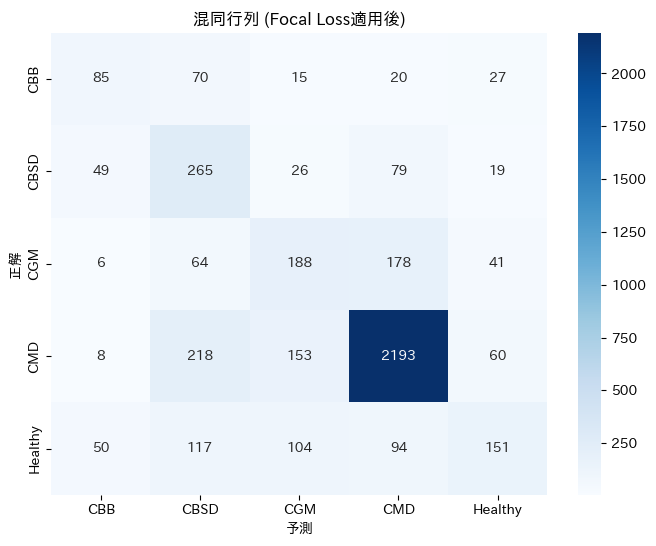


--- クラスごとの詳細な成績表 ---
              precision    recall  f1-score   support

         CBB       0.43      0.39      0.41       217
        CBSD       0.36      0.61      0.45       438
         CGM       0.39      0.39      0.39       477
         CMD       0.86      0.83      0.84      2632
     Healthy       0.51      0.29      0.37       516

    accuracy                           0.67      4280
   macro avg       0.51      0.50      0.49      4280
weighted avg       0.69      0.67      0.67      4280



In [ ]:
class_names = ['CBB', 'CBSD', 'CGM', 'CMD', 'Healthy']

def evaluate_model_details(model, loader, device):
    model.eval() # テストモードに切り替え
    all_preds = []
    all_labels = []

    with torch.no_grad():
        for images, labels in loader:
            images = images.to(device)
            outputs = model(images)
            _, preds = torch.max(outputs, 1)

            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    # 混同行列
    cm = confusion_matrix(all_labels, all_preds)

    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=class_names, yticklabels=class_names)
    plt.xlabel('予測')
    plt.ylabel('正解')
    plt.title('混同行列 (Focal Loss適用後)')
    plt.show()

    # Classification Report
    print("\n--- クラスごとの詳細な成績表 ---")
    print(classification_report(all_labels, all_preds, target_names=class_names))

evaluate_model_details(model, val_loader, device)

#### モデルはどのような判断で画像を予測したのか確認

正解: CMD
予測: CMD


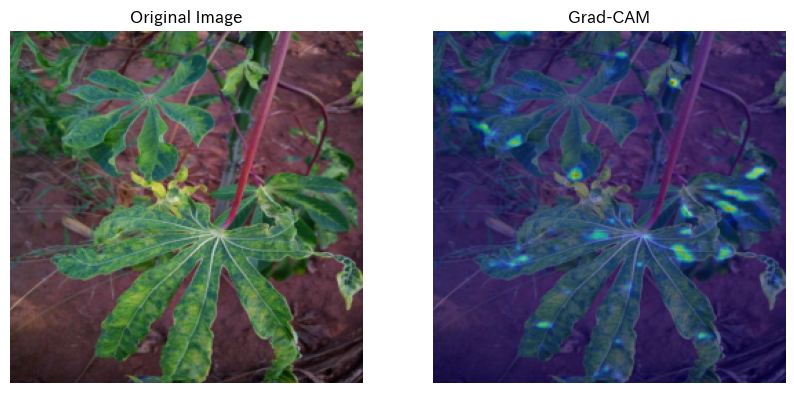

In [ ]:
def generate_gradcam(model, image_tensor, target_class, target_layer):
    """
    Grad-CAMのヒートマップを生成する関数
    """
    # 勾配を保存するための変数
    gradients = []
    def save_gradient(grad):
        gradients.append(grad)

    # 1. 順伝播
    model.eval()
    # 対象の層（conv3など）の出力（活性化）を取得できるようにフックを設定
    features = None
    # ターゲット層の出力を取得するための処理
    x = image_tensor
    # 手動で順伝播を追い、ターゲット層の出力を保持する
    x = model.pool(F.relu(model.conv1(x)))
    x = model.pool(F.relu(model.conv2(x)))
    features = model.conv3(x) # 活性化関数(ReLU)の直前の値を使用
    features.register_hook(save_gradient)

    # 最終的な出力を得るために残りの層も計算
    output_features = model.pool(F.relu(features))
    output_features = output_features.view(-1, 64 * 32 * 32)
    output = model.fc2(F.relu(model.fc1(output_features)))

    # 2. 逆伝播
    model.zero_grad()
    # ターゲットクラスのスコアを取得
    score = output[0][target_class]
    # スコアを微分して勾配を計算
    score.backward()

    # 3. ヒートマップの合成
    # 保存した勾配を取得
    grads = gradients[0]
    # 各チャンネル（64枚）の勾配の平均を重みとする
    weights = torch.mean(grads, dim=(2, 3), keepdim=True)
    # 重みと特徴量を掛け合わせて合成
    cam = torch.sum(weights * features, dim=1).squeeze().cpu().detach().numpy()

    # ReLUを適用（正の影響のみ抽出）し、0-1に正規化
    cam = np.maximum(cam, 0)
    cam = cam / (np.max(cam) + 1e-10)
    # 元の画像サイズ(256x256)にリサイズ
    cam = cv2.resize(cam, (256, 256))

    return cam

def plot_gradcam(image_tensor, cam):
    """
    元の画像とヒートマップを重ねて表示する関数
    """
    # Tensorを画像に戻す
    img = image_tensor.squeeze().cpu().permute(1, 2, 0).numpy()

    # ヒートマップをカラーマップ（JET）に変換
    heatmap = cv2.applyColorMap(np.uint8(255 * cam), cv2.COLORMAP_JET)
    heatmap = cv2.cvtColor(heatmap, cv2.COLOR_BGR2RGB) / 255.0

    # 元の画像とヒートマップを合成（重み 0.5ずつ）
    result = heatmap * 0.4 + img * 0.6

    plt.figure(figsize=(10, 5))
    plt.subplot(1, 2, 1)
    plt.imshow(img)
    plt.title("Original Image")
    plt.axis('off')

    plt.subplot(1, 2, 2)
    plt.imshow(result)
    plt.title("Grad-CAM")
    plt.axis('off')
    plt.show()

# 実行例：検証データの最初の1枚で試す
dataiter = iter(val_loader)
images, labels = next(dataiter)
idx = 2 # 2番目の画像
img_t = images[idx].unsqueeze(0).to(device)

# AIが予測したクラスに対してGrad-CAMを実行
model.eval()
with torch.no_grad():
    output = model(img_t)
    _, pred = torch.max(output, 1)

print(f"正解: {class_names[labels[idx]]}")
print(f"予測: {class_names[pred.item()]}")

# ヒートマップ生成
cam = generate_gradcam(model, img_t, pred.item(), model.conv3)
plot_gradcam(img_t, cam)

In [ ]:
# 一番当てはまりがよい予測画像の判定結果を確認

# クラスごとの最高確率の画像を保存
best_predictions = {i: {'prob': 0.0, 'image_tensor' : None} for i in range(len(class_names))}

model.eval()
with torch.no_grad():
    for images, labels in val_loader:
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)

        # 出力を確率に変換
        probs = F.softmax(outputs, dim=1)

        for j in range(images.size(0)):
            label = labels[j].item()
            prob = probs[j][label].item() # 確率
            pred = torch.argmax(probs[j]).item() # 予測

            # 正解かつ最高の確率
            if label == pred and prob > best_predictions[label]['prob']:
                best_predictions[label]['prob'] = prob
                best_predictions[label]['image_tensor'] = images[j].cpu().clone()

print('Grad-CAMをクラスごとに出力')

for class_idx in range(len(class_names)):
    best_data = best_predictions[class_idx]
    best_prob = best_data['prob']
    best_img_t = best_data['image_tensor']

    class_name = class_names[class_idx]

    print(f'【{class_name}】のベスト予測（確率：{best_prob * 100:.2f}%）')

    img_t_device = best_img_t.unsqueeze(0).to(device)
    cam = generate_gradcam(model, img_t_device, class_idx, model.conv3)
    plot_gradcam(img_t_device, cam)

Output hidden; open in https://colab.research.google.com to view.

#### 結果および考察：

* 予測精度の限界：
    
    前回の強力すぎるペナルティから脱却こそしたが、結果として、CMDを除いた葉っぱの状態の特定は困難であることがわかった。
    
    少数派クラスにおけるPrecisionおよびRecallは30～40%台にとどまっており、実用的な予測モデルとしては確証が低い結果となった。

* モデルの解釈可能性について:：
    
    AIが画像のどこを根拠にクラス判定をしたのか可視化（Grad-CAM）を行った結果、病変部位を正しく捉えているケースもある一方で、葉ではなく背景の「土」などの特徴に依存して判定を行っているケースが散見された。単純なCNN構造では、複雑な葉脈と背景の分離ができていないことが示唆される。

* 今後の対応：

    これ以上のハイパーパラメータチューニングによる精度改善も考えられるが、モデル構造自体の限界が見えており、計算コストの観点からも費用対効果が薄いと判断した。そのため、本ベースラインモデルでの検証はここで見送りとし、高精度モデルでの実装に移行する。

## ResNetの実装

#### 今回採用したResNetとは…



* **ResNetについて**

    **ResNet（Residual Network）** は、2015年にMicrosoftが開発した画像認識のためのCNN（畳み込みニューラルネットワーク）モデルである。

    最大の特徴は **「残差ブロック（Residual Block）」** と **「スキップ接続（Skip Connection）」** の導入であり、これにより従来の従来のディープラーニングでは難しかった深層化を可能にした。

    ちなみに、ResNet-50は50層の深さを持つCNNのことであり、他にも用途に合わせてResNet-18やResNet-152などが存在する。

    通常、ニューラルネットワークは50層も重ねると **「勾配消失問題（逆伝播の際に情報が薄れてしまい、学習がうまく進まなくなる現象）」** が発生するが、ResNetは残差ブロックを導入したことでこの問題を解決した。

* **ResNet-50の特徴（残差ブロックとスキップ接続）**


    （ResNet-50における）残差ブロックとは、主に3つの層が1セットになっており、これを16セット繋げることで深く学習できる仕組みになっている。
    
    また、スキップ接続はブロックごとで出力された変換結果 $F(x)$ に、入力値 $x$ をそのまま加算する。

    $H(x) = F(x) + x$

    これにより、最悪の場合でも恒等変換（入力 $x$ をそのまま出力すること）を次の層に流すことができる。
    つまり、ネットワークは「必要な差分（残差）だけを学習すればいい」という状態になる。

    イメージとして、ネットワーク内では以下2通りの進み方が平行して処理されている。
    
    * 通常通り、1つ1つの層をくぐって変換される処理
    * ブロックごとの出力に加算するために、層を迂回して（スキップして）進む $x$

    重要なのは、スキップ接続を通る $x$ は、単純に最初の入力が並列して流れ続けるのではなく、1ブロックごとの出力結果によって「新しい $x$」に更新されながら流れていく点である。

    * 学習の進み方

        * ブロック1： $x_1 = F_1(x_0) + x_0$
        * ブロック2： $x_2 = F_2(x_1) + x_1$
        * $\dots$
        * ブロックn： $x_n = F_n(x_{n-1}) + x_{n-1}$

    つまり、一般化すると以下のように情報が伝播していく。
    
    $x_{n+1} = F_n(x_n) + x_n \quad \text{（新しい特徴 ＝ 変換結果 ＋ 前の特徴）}$

    この「足し算」の構造により、逆伝播時（学習時）にも勾配が途切れることなく直接前の層へ伝わりやすくなり、非常に深いネットワークでも勾配消失問題が起きにくくなっている。


### 転移学習の実装

* 重みを固定し、事前学習済みResNet-50を特徴抽出器として利用
* 最終の全結合層のみ、今回の目的（5クラス分類）に合わせて学習を許可

In [ ]:
import torchvision.models as models

# ResNet50を呼び出す
model = models.resnet50(weights=models.ResNet50_Weights.DEFAULT)

# 50層の重みを固定（凍結）
for param in model.parameters():
    param.requires_grad = False

# ResNet50の最後の全結合層（fc）の入力サイズ(2048)を取得
num_ftrs = model.fc.in_features

# 出力層は2048の入力を受け付けてクラス数5の出力に変更する
# ※新しく付け替えたこの層だけは、自動的に requires_grad = True となる
model.fc = nn.Linear(in_features=num_ftrs, out_features=5)

model = model.to(device)

# 出力層だけパラメータの更新をする
optimizer = torch.optim.Adam(model.fc.parameters(), lr=0.001)

# ペナルティを優しくしたLoss関数を適用
criterion = FocalLoss(weight=class_weights, gamma=1.0)
num_epochs = 5

# 転移学習（ResNET）の実装
for epoch in range(num_epochs):
    train_loss, train_acc = train_one_epoch(model, train_loader, optimizer, criterion, device)
    val_loss, val_acc = validate_one_epoch(model, val_loader, criterion, device)

    print(f'Epoch [{epoch+1}/{num_epochs}]')
    print(f'Train Loss: {train_loss:.4f}, Train Acc: {train_acc:.4f}')
    print(f'Val Loss:   {val_loss:.4f}, Val Acc:   {val_acc:.4f}')

Epoch [1/5]
Train Loss: 0.5518, Train Acc: 0.6931
Val Loss:   0.4929, Val Acc:   0.7063
Epoch [2/5]
Train Loss: 0.4555, Train Acc: 0.7307
Val Loss:   0.4414, Val Acc:   0.7350
Epoch [3/5]
Train Loss: 0.4302, Train Acc: 0.7448
Val Loss:   0.4459, Val Acc:   0.7224
Epoch [4/5]
Train Loss: 0.4164, Train Acc: 0.7442
Val Loss:   0.4421, Val Acc:   0.7185
Epoch [5/5]
Train Loss: 0.4090, Train Acc: 0.7462
Val Loss:   0.4340, Val Acc:   0.7238


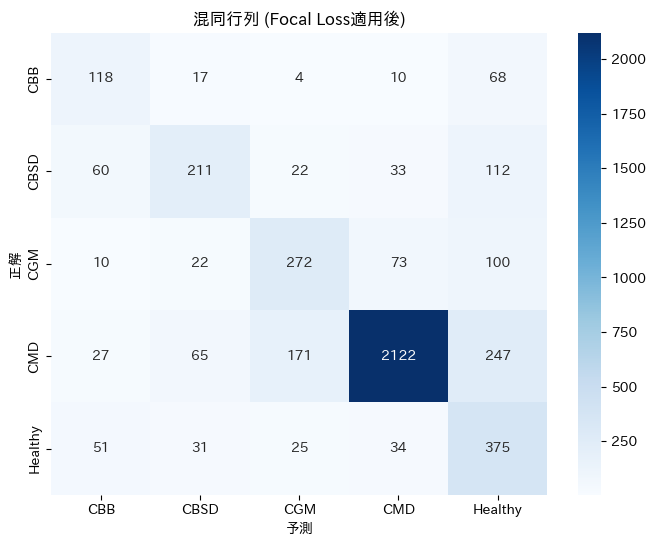


--- クラスごとの詳細な成績表 ---
              precision    recall  f1-score   support

         CBB       0.44      0.54      0.49       217
        CBSD       0.61      0.48      0.54       438
         CGM       0.55      0.57      0.56       477
         CMD       0.93      0.81      0.87      2632
     Healthy       0.42      0.73      0.53       516

    accuracy                           0.72      4280
   macro avg       0.59      0.63      0.60      4280
weighted avg       0.77      0.72      0.74      4280



In [ ]:
class_names = ['CBB', 'CBSD', 'CGM', 'CMD', 'Healthy']

def evaluate_model_details(model, loader, device):
    model.eval() # テストモードに切り替え
    all_preds = []
    all_labels = []

    with torch.no_grad():
        for images, labels in loader:
            images = images.to(device)
            outputs = model(images)
            _, preds = torch.max(outputs, 1)

            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    # 混同行列
    cm = confusion_matrix(all_labels, all_preds)

    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=class_names, yticklabels=class_names)
    plt.xlabel('予測')
    plt.ylabel('正解')
    plt.title('混同行列 (Focal Loss適用後)') # 転移学習適用後のミス
    plt.show()

    # Classification Report
    print("\n--- クラスごとの詳細な成績表 ---")
    print(classification_report(all_labels, all_preds, target_names=class_names))

evaluate_model_details(model, val_loader, device)

↑

**※コード転記によりFocalLoss適用後となっているが、実施は適用していない**

---

### 結果

* 事前学習モデルの精度の高さ:

    ネットワークの重みを凍結し、最終層のみを学習させる「単純な転移学習」のみを実施した段階であるにもかかわらず、パラメータチューニングを重ねた自作のCNNのスコアをほぼすべての指標で上回る結果となった。

* 多数派への偏りの適応:

    自作CNNの初期段階で見られた「とりあえず多数派であるCMDと予測しておく」といったモデルの単純な振る舞いが改善されている。これは、ResNet-50が事前学習によって獲得した強力な特徴抽出により、少数派のクラスであっても、それぞれの病気特有の視覚的特徴をしっかりと捉え分けている証拠であると言える。

>
> 【参考】
>
>  前回の結果（パラメータチューニングしたシンプルCNN）
>
>       --- クラスごとの詳細な成績表 ---
>              precision    recall  f1-score   support
>
>         CBB       0.43      0.39      0.41       217
>        CBSD       0.36      0.61      0.45       438
>         CGM       0.39      0.39      0.39       477
>         CMD       0.86      0.83      0.84      2632
>     Healthy       0.51      0.29      0.37       516
>
>       accuracy                           0.67      4280
>     macro avg       0.51      0.50      0.49      4280
>     weighted avg       0.69      0.67      0.67      4280
>

### ファインチューニングの実装

* モデル全体の重み固定を解除し、すべての層の学習を許可
* 学習率（Learning Rate）を十分に小さく設定し、構築済みの特徴抽出能力を壊さずに微調整
* 損失関数にパラメータを緩和したFocal Lossを適用し、難問クラスに対してアプローチ

In [ ]:
# セッション切れにより再定義

# αの実装：データ数による調整パラメータ

# 学習データ内の各クラスの枚数をカウント
class_counts = train_df['label'].value_counts().sort_index().values
print(f'各クラスの枚数：{class_counts}')

# 枚数の「平方根の逆数」をとることで、極端すぎる重みを和らげる
weights = 1.0 /np.sqrt(class_counts)

# 重みの合計がクラス数になるように正規化
weights = weights / weights.sum() * len(class_counts)
class_weights = torch.FloatTensor(weights).to(device)
print(f'和らげた重み：{class_weights}')

model = SimpleCNN().to(device)

# Criterion を変更（パラメータαとγを適用）
criterion = FocalLoss(weight=class_weights, gamma=1.0) # gammaを1.0に変更
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

各クラスの枚数：[  870  1751  1909 10526  2061]
和らげた重み：tensor([1.5073, 1.0625, 1.0176, 0.4333, 0.9793], device='cuda:0')


In [ ]:
# 50層の重みの更新を解除
for param in model.parameters():
    param.requires_grad = True

# model.fc.parameters() ⇒ model.parameters() に変更（すべてを対象とする）
optimizer_ft = torch.optim.Adam(model.parameters(), lr=0.0001) # 学習率（lr）を0.0001に下げる

# Loss関数は優しめを続投
criterion_ft = FocalLoss(weight=class_weights, gamma=1.0)
num_epochs_ft = 5

# ファインチューニングの実装開始
for epoch in range(num_epochs_ft):
    train_loss, train_acc = train_one_epoch(model, train_loader, optimizer_ft, criterion_ft, device)
    val_loss, val_acc = validate_one_epoch(model, val_loader, criterion_ft, device)

    print(f'Epoch [{epoch+1}/{num_epochs_ft}]')
    print(f'Train Loss: {train_loss:.4f}, Train Acc: {train_acc:.4f}')
    print(f'Val Loss:   {val_loss:.4f}, Val Acc:   {val_acc:.4f}')

Epoch [1/5]
Train Loss: 0.3267, Train Acc: 0.8047
Val Loss:   0.3038, Val Acc:   0.8189
Epoch [2/5]
Train Loss: 0.2515, Train Acc: 0.8485
Val Loss:   0.2903, Val Acc:   0.8248
Epoch [3/5]
Train Loss: 0.2162, Train Acc: 0.8691
Val Loss:   0.2739, Val Acc:   0.8411
Epoch [4/5]
Train Loss: 0.1893, Train Acc: 0.8820
Val Loss:   0.2859, Val Acc:   0.8507
Epoch [5/5]
Train Loss: 0.1630, Train Acc: 0.8913
Val Loss:   0.2840, Val Acc:   0.8381


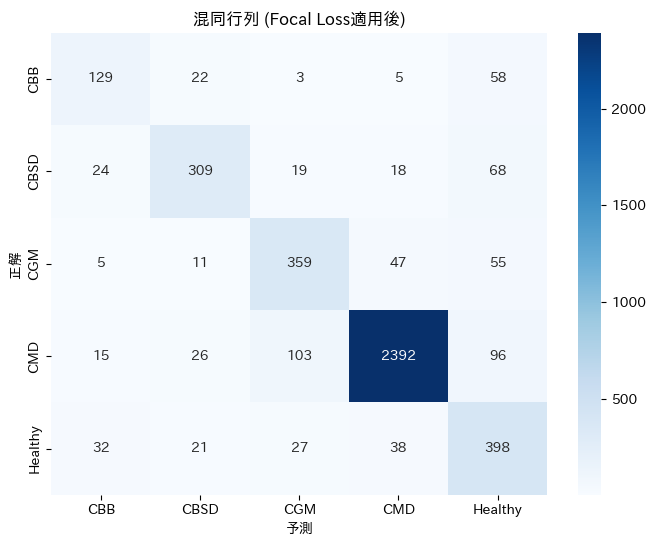


--- クラスごとの詳細な成績表 ---
              precision    recall  f1-score   support

         CBB       0.63      0.59      0.61       217
        CBSD       0.79      0.71      0.75       438
         CGM       0.70      0.75      0.73       477
         CMD       0.96      0.91      0.93      2632
     Healthy       0.59      0.77      0.67       516

    accuracy                           0.84      4280
   macro avg       0.73      0.75      0.74      4280
weighted avg       0.85      0.84      0.84      4280



In [ ]:
evaluate_model_details(model, val_loader, device)

### 結果

* 転移学習単体では解消しきれなかったデータ不均衡への適応：

    転移学習のみでも一定の精度は得られていたが、Focal Lossを用いた不均衡クラスへのアプローチ（ファインチューニング）を組み合わせたことで、モデルの適応力がさらに向上した。結果として、モデル全体のAccuracyが84%に達しただけでなく、すべての指標において過去最高の結果を叩き出している。
    
    特筆すべきは、全クラスを平等に評価する指標である macro avg の F1-score が 0.60 から 0.74 へと劇的に向上している点であり、これは少数派クラス（CBBやCBSDなど）の特徴もモデルが正確に捉え切ったことを証明している。

* Simple CNNでの試行錯誤がもたらした相乗効果：

    実務においてCNNモデルをゼロから作成する機会は少ないかもしれないが、3月に挑戦したときに「画像分類タスクにおいてどのような手法が効果的か」を一から探り、Focal Lossやパラメータチューニングの挙動を根本から理解したことが、結果として事前学習モデル（ResNet）のポテンシャルを限界まで引き出すための強力な「スパイス」となったと言える。

## Grad-CAMでモデルが「画像のどの部分を見て判断したか」を可視化

In [ ]:
def generate_gradcam(model, image_tensor, target_class, target_layer):
    """
    ResNet用に関数の中身を修正
    """
    # 横取りしたデータを保存するリスト
    saved_features = []
    saved_gradients = []

    # フック関数：順伝播の時に特徴量を保存し、さらに逆伝播の時の勾配も保存するよう仕掛ける
    def hook_fn(module, input, output):
        saved_features.append(output)
        # その層の出力（テンソル）に直接逆伝播のフックを掛ける
        output.register_hook(lambda grad: saved_gradients.append(grad))

    # ターゲット層にフックを登録
    handle = target_layer.register_forward_hook(hook_fn)

    # 1. 順伝播
    model.eval()
    output = model(image_tensor)

    # 2. 逆伝播
    model.zero_grad()
    score = output[0][target_class]
    score.backward()

    # フックを解除
    handle.remove()

    # 3. ヒートマップの合成
    # 保存した特徴量と勾配を取り出す
    features = saved_features[0].cpu().data.numpy().squeeze()
    grads = saved_gradients[0].cpu().data.numpy().squeeze()

    # 各チャンネルの勾配の平均を重みとする
    weights = np.mean(grads, axis=(1, 2))

    # 重みと特徴量を掛け合わせて合成
    cam = np.zeros(features.shape[1:], dtype=np.float32)
    for i, w in enumerate(weights):
        cam += w * features[i, :, :]

    # ReLUを適用（正の影響のみ抽出）し、0-1に正規化
    cam = np.maximum(cam, 0)
    cam = cam / (np.max(cam) + 1e-10)

    # 元の画像サイズ(256x256)にリサイズ
    cam = cv2.resize(cam, (256, 256))

    return cam

In [ ]:
# 一番当てはまりがよい予測画像の判定結果を確認

# クラスごとの最高確率の画像を保存
best_predictions = {i: {'prob': 0.0, 'image_tensor' : None} for i in range(len(class_names))}

model.eval()
with torch.no_grad():
    for images, labels in val_loader:
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)

        # 出力を確率に変換
        probs = F.softmax(outputs, dim=1)

        for j in range(images.size(0)):
            label = labels[j].item()
            prob = probs[j][label].item() # 確率
            pred = torch.argmax(probs[j]).item() # 予測

            # 正解かつ最高の確率
            if label == pred and prob > best_predictions[label]['prob']:
                best_predictions[label]['prob'] = prob
                best_predictions[label]['image_tensor'] = images[j].cpu().clone()

print('Grad-CAMをクラスごとに出力')

for class_idx in range(len(class_names)):
    best_data = best_predictions[class_idx]
    best_prob = best_data['prob']
    best_img_t = best_data['image_tensor']

    class_name = class_names[class_idx]

    print(f'【{class_name}】のベスト予測（確率：{best_prob * 100:.2f}%）')

    img_t_device = best_img_t.unsqueeze(0).to(device)
    cam = generate_gradcam(model, img_t_device, class_idx, model.layer4)
    plot_gradcam(img_t_device, cam)

Output hidden; open in https://colab.research.google.com to view.


=== 予測エラー：ワースト3 ===

【ワースト1】 モデルの確信度: 98.84%
（正解: CGM × 予測: Healthy）


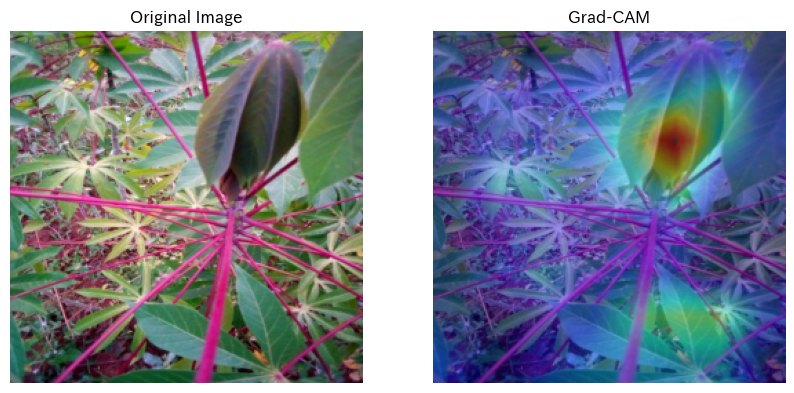

【ワースト2】 モデルの確信度: 98.70%
（正解: CMD × 予測: Healthy）


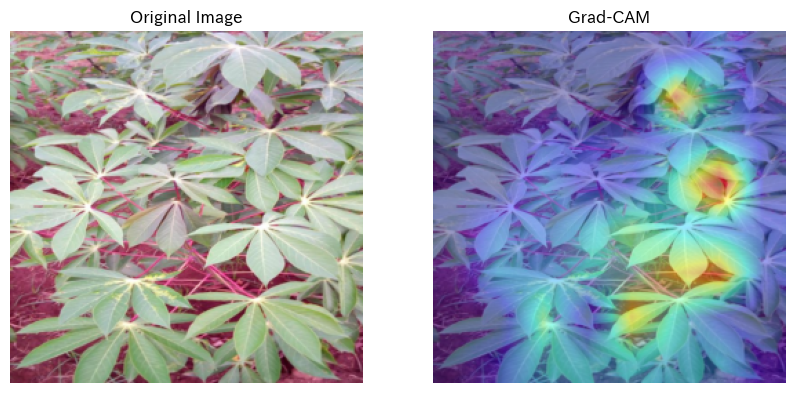

【ワースト3】 モデルの確信度: 97.53%
（正解: CMD × 予測: CGM）


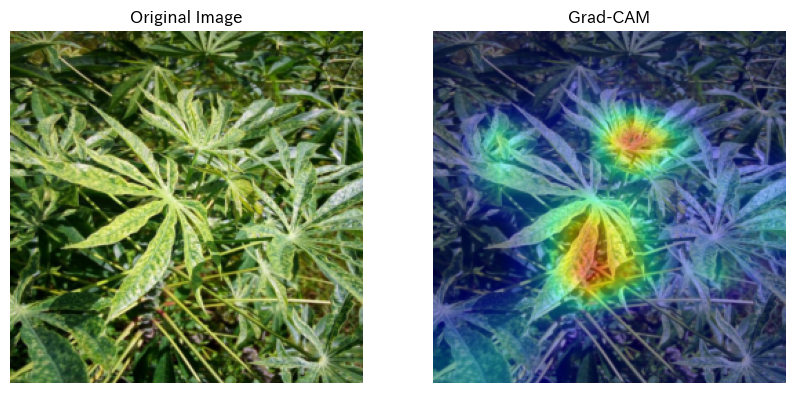

In [ ]:
# 予測確率が高い誤答を探索する

# 誤答リスト（確率が高い順にソートして保存する）
wrong_predictions = []

model.eval()
with torch.no_grad():
    for images, labels in val_loader:
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)

        # 出力を確率に変換
        probs = F.softmax(outputs, dim=1)

        for j in range(images.size(0)):
            label = labels[j].item()
            pred_prob, pred = torch.max(probs[j], 0) # モデルが最も確率が高いと判断した情報
            pred_prob = pred_prob.item()
            pred = pred.item()

            # もし「予測がハズレた」場合
            if label != pred:
                wrong_predictions.append({
                    'prob': pred_prob, # モデルが確信した確率
                    'image_tensor': images[j].cpu().clone(),
                    'true_label': label,
                    'pred_label': pred
                })

# 確信確率（prob）が高い順にソート
wrong_predictions = sorted(wrong_predictions, key=lambda x: x['prob'], reverse=True)

# 2. 上位3枚の予測確率が高い誤答を Grad-CAM で解析する
num_to_show = 3 # 表示する枚数

print(f"\n=== 予測エラー：ワースト{num_to_show} ===\n")

# もし誤答がnum_to_show枚より少ない場合は、全件表示
for i in range(min(num_to_show, len(wrong_predictions))):
    wrong_data = wrong_predictions[i]
    wrong_prob = wrong_data['prob']
    wrong_img_t = wrong_data['image_tensor']

    true_name = class_names[wrong_data['true_label']]
    pred_name = class_names[wrong_data['pred_label']]

    print(f"【ワースト{i+1}】 モデルの確信度: {wrong_prob * 100:.2f}%")
    print(f"（正解: {true_name} × 予測: {pred_name}）")

    img_t_device = wrong_img_t.unsqueeze(0).to(device)

    # SimpleCNN仕様の「model.conv3」から「model.layer4」に変更
    cam = generate_gradcam(model, img_t_device, wrong_data['pred_label'], model.layer4)
    plot_gradcam(img_t_device, cam)

In [ ]:
print("=== ワースト3画像の全クラス確率分布 ===\n")

model.eval()
with torch.no_grad():
    # 上位3枚だけを取り出す
    for i in range(min(3, len(wrong_predictions))):
        wrong_data = wrong_predictions[i]

        # 保存しておいた画像テンソルを取り出し、推論用の形にする
        img_t_device = wrong_data['image_tensor'].unsqueeze(0).to(device)

        # モデルにもう一度見せて、出力を確率に変換
        output = model(img_t_device)
        probs = F.softmax(output, dim=1).squeeze().cpu().numpy()

        true_name = class_names[wrong_data['true_label']]
        pred_name = class_names[wrong_data['pred_label']]

        print(f"【ワースト{i+1}】 (正解: {true_name} × 予測: {pred_name})")
        print("-" * 35)

        # 全クラスの確率を棒グラフ風に出力
        for class_idx, class_name in enumerate(class_names):
            prob_percent = probs[class_idx] * 100

            # モデルが選んだ答えにマークをつける
            mark = "予測" if class_idx == wrong_data['pred_label'] else "         "

            # 見やすくフォーマット
            print(f"{class_name:7s} : {prob_percent:>6.2f}% {mark}")
        print("\n")

=== ワースト3画像の全クラス確率分布 ===

【ワースト1】 (正解: CGM × 予測: Healthy)
-----------------------------------
CBB     :   0.00%          
CBSD    :   0.17%          
CGM     :   0.94%          
CMD     :   0.05%          
Healthy :  98.84% 予測


【ワースト2】 (正解: CMD × 予測: Healthy)
-----------------------------------
CBB     :   0.03%          
CBSD    :   0.08%          
CGM     :   0.22%          
CMD     :   0.97%          
Healthy :  98.70% 予測


【ワースト3】 (正解: CMD × 予測: CGM)
-----------------------------------
CBB     :   0.00%          
CBSD    :   0.01%          
CGM     :  97.53% 予測
CMD     :   2.46%          
Healthy :   0.01%          




### おまけ：アプリ（Streamlit）を試してみる！

In [ ]:
# 現在のモデルをファイルに保存する
# アプリのコードでこのファイルを読み込む
model_path = 'cassava_resnet50_ft.pth'
torch.save(model.state_dict(), model_path)
print(f'モデルを {model_path} に保存')

# ColabでStreamlitを外部公開するためのlocaltunnelをインストール
!npm install -g localtunnel

モデルを cassava_resnet50_ft.pth に保存
⠙⠹⠸⠼⠴⠦⠧⠇⠏⠋⠙⠹⠸⠼⠴⠦⠧⠇⠏⠋⠙⠹⠸⠼
changed 22 packages in 3s
⠼
⠼3 packages are looking for funding
⠼  run `npm fund` for details
⠼

In [ ]:
%%writefile app.py
import streamlit as st
import torch.nn.functional as F
from torchvision import models

# 設定
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
class_names = ['CBB', 'CBSD', 'CGM', 'CMD', 'Healthy']
model_path = 'cassava_resnet50_ft.pth'
target_image_size = (256, 256)

# モデル構造の定義と読み込み
@st.cache_resource # モデルをキャッシュして、再読み込みを高速化
def load_model():
    # 転移学習時と同じResNet50の構造を作成
    model = models.resnet50(weights=None)
    num_ftrs = model.fc.in_features
    model.fc = nn.Linear(num_ftrs, len(class_names))

    # 保存した重みを読み込む
    model.load_state_dict(torch.load(model_path, map_location=device))
    model = model.to(device)
    model.eval()
    return model

# 画像の前処理設定
# 学習時と同じサイズ変更とTensor化を行う
transform = transforms.Compose([
    transforms.Resize(target_image_size),
    transforms.ToTensor(),
])

# 汎用版 Grad-CAM 関数（フック利用版）
def generate_gradcam(model, image_tensor, target_class, target_layer):
    saved_features = []
    saved_gradients = []
    def hook_fn(module, input, output):
        saved_features.append(output)
        output.register_hook(lambda grad: saved_gradients.append(grad))
    handle = target_layer.register_forward_hook(hook_fn)
    model.eval()
    output = model(image_tensor)
    model.zero_grad()
    score = output[0][target_class]
    score.backward()
    handle.remove()
    features = saved_features[0].cpu().data.numpy().squeeze()
    grads = saved_gradients[0].cpu().data.numpy().squeeze()
    weights = np.mean(grads, axis=(1, 2))
    cam = np.zeros(features.shape[1:], dtype=np.float32)
    for i, w in enumerate(weights):
        cam += w * features[i, :, :]
    cam = np.maximum(cam, 0)
    cam = cam / (np.max(cam) + 1e-10)
    cam = cv2.resize(cam, target_image_size)
    return cam

# 元画像とヒートマップの合成関数
def create_gradcam_plot(image_pil, cam):
    # PIL画像をnumpy配列(0-1)に変換
    img = np.array(image_pil.resize(target_image_size)) / 255.0

    # ヒートマップをカラーマップ(JET)に変換
    heatmap = cv2.applyColorMap(np.uint8(255 * cam), cv2.COLORMAP_JET)
    heatmap = cv2.cvtColor(heatmap, cv2.COLOR_BGR2RGB) / 255.0

    # 合成（重み 0.4:0.6）
    result = heatmap * 0.4 + img * 0.6

    # Matplotlibで画像を作成
    fig, ax = plt.subplots(1, 2, figsize=(10, 5))
    ax[0].imshow(img)
    ax[0].set_title("Original Image")
    ax[0].axis('off')

    ax[1].imshow(result)
    ax[1].set_title("Grad-CAM (Attention)")
    ax[1].axis('off')

    return fig

# Streamlit UI
st.set_page_config(page_title="Cassava Disease AI", page_icon="🌿")

st.title("🌿 Cassava Leaf Disease Diagnostic AI")
st.write("アップロードされたキャッサバの画像（葉、または根）から、5種類の病気をモデルが高精度に判定し、どこに注目したかを視覚化します。")

# モデルの読み込み
with st.spinner('モデルを起動中'):
    model = load_model()

# 画像アップローダー
uploaded_file = st.file_uploader("キャッサバの画像をアップロードしてください", type=["jpg", "jpeg", "png"])

if uploaded_file is not None:
    # 1. アップロードされた画像を画面に表示
    image = Image.open(uploaded_file).convert('RGB')
    st.image(image, caption='アップロードされた画像', use_column_width=True)
    st.write("")

    # 判定ボタン
    if st.button('病気を判定する'):
        with st.spinner('画像を解析中'):
            # 2. 画像の前処理
            img_t = transform(image).unsqueeze(0).to(device)

            # 3. 推論（予測）
            with torch.no_grad():
                output = model(img_t)
                probs = F.softmax(output, dim=1) # 確率に変換
                prob, pred = torch.max(probs, 1) # 最大確率とそのクラス

            pred_class_name = class_names[pred.item()]
            pred_prob_percent = prob.item() * 100

            # 予測結果の表示
            st.success(f"### 判定結果: 【{pred_class_name}】")
            st.write(f"確信度: **{pred_prob_percent:.2f}%**")

            # 4. Grad-CAMの生成（最後の特徴層 model.layer4 を指定）
            with st.spinner('Grad-CAMヒートマップを生成中.'):
                cam = generate_gradcam(model, img_t, pred.item(), model.layer4)

                # 5. 結果のプロット作成と表示
                fig = create_gradcam_plot(image, cam)
                st.pyplot(fig)

                st.write("**ヒートマップの見方**: 赤い部分はモデルが判定の決め手とした場所です。CBSDの根の画像の場合、褐色条斑の部分が赤くなっているか確認してください。")

st.write("---")
st.caption("Developed by Cassava DL Journey Project. Model: ResNet50 (Fine-Tuned).")

Overwriting app.py


In [ ]:
# 1. Colabの外部IPアドレスを取得（localtunnelのパスワードになります）
# 出力されたIPアドレスをコピーしてください
print("あなたのlocaltunnelパスワード（Colab外部IP）はこれです：")
!curl ipv4.icanhazip.com

print("-" * 30)

# 2. Streamlitアプリをバックグラウンドで起動
!streamlit run app.py &>/dev/null &

print("Streamlitアプリを起動しました。")
print("下のURLをクリックし、開いたページで上のパスワード（IP）を入力して『Submit』を押してください。")
print("-" * 30)

# 3. localtunnelを起動して、公開URLを取得
# Tunnel URL: https://XXXXXX.localtunnel.me というURLが表示されます
!npx localtunnel --port 8501

あなたのlocaltunnelパスワード（Colab外部IP）はこれです：
34.125.145.222
------------------------------
Streamlitアプリを起動しました。
下のURLをクリックし、開いたページで上のパスワード（IP）を入力して『Submit』を押してください。
------------------------------
⠙⠹⠸⠼⠴⠦⠧your url is: https://clean-rings-teach.loca.lt
^C
